# Hotel Guest Satisfaction Classification Using Natural Language Processing

# 1. Business Context and Problem Formulation

Written customer reviews are a huge source of data for hotels, making it hard and time-consuming to manually analyze them. Recognising when a customer is unhappy as soon as possible can assist hotels in making changes to the service quality and thus enhance the customer experience.

The goal of this project is to create a binary classification model, by applying NLP techniques, that can classify a hotel review as Satisfied or Dissatisfied based on the customers' written feedback. This target is based on the Reviewer_Score: any score of 7.5 or less is considered Dissatisfied and any score higher than 7.5 are considered Satisfied.

Hotel review data set is collected from kaggle and includes reviews from customers and relevant information regarding hotels in Europe (Kaggle n.d.). The values of the fields Positive_Review and Negative_Review are taken to be the primary textual input for the NLP task.

Business goal: An automated and scalable way to analyse customer feedback. The forecasts could be used by hotel personnel to focus on potentially unhappy reviews, assist with quicker recovery of service, and identify problems that arise with customers' experiences.

It can be regarded as a supervised binary text classification problem. The input is the written review text and output is a classification label: Satisfied or Dissatisfied.

## 2. Import Libraries and Load the Dataset

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

C:\Users\HP\anaconda3\lib\site-packages\scipy\__init__.py:155: UserWarning: A NumPy version >=1.18.5 and <1.25.0 is required for this version of SciPy (detected version 1.26.4
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


In [3]:
df = pd.read_csv("Hotel_Reviews.csv")

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (515738, 17)


,Hotel_Address,Additional_Number_of_Scoring,Review_Date,Average_Score,Hotel_Name,Reviewer_Nationality,Negative_Review,Review_Total_Negative_Word_Counts,Total_Number_of_Reviews,Positive_Review,Review_Total_Positive_Word_Counts,Total_Number_of_Reviews_Reviewer_Has_Given,Reviewer_Score,Tags,days_since_review,lat,lng
0,s Gravesandestraat 55 Oost 1092 AA Amsterdam ...,194,8/3/2017,7.7,Hotel Arena,Russia,I am so angry that i made this post available...,397,1403,Only the park outside of the hotel was beauti...,11,7,2.9,"[' Leisure trip ', ' Couple ', ' Duplex Double...",0 days,52.360576,4.915968
1,s Gravesandestraat 55 Oost 1092 AA Amsterdam ...,194,8/3/2017,7.7,Hotel Arena,Ireland,No Negative,0,1403,No real complaints the hotel was great great ...,105,7,7.5,"[' Leisure trip ', ' Couple ', ' Duplex Double...",0 days,52.360576,4.915968
2,s Gravesandestraat 55 Oost 1092 AA Amsterdam ...,194,7/31/2017,7.7,Hotel Arena,Australia,Rooms are nice but for elderly a bit difficul...,42,1403,Location was good and staff were ok It is cut...,21,9,7.1,"[' Leisure trip ', ' Family with young childre...",3 days,52.360576,4.915968
3,s Gravesandestraat 55 Oost 1092 AA Amsterdam ...,194,7/31/2017,7.7,Hotel Arena,United Kingdom,My room was dirty and I was afraid to walk ba...,210,1403,Great location in nice surroundings the bar a...,26,1,3.8,"[' Leisure trip ', ' Solo traveler ', ' Duplex...",3 days,52.360576,4.915968
4,s Gravesandestraat 55 Oost 1092 AA Amsterdam ...,194,7/24/2017,7.7,Hotel Arena,New Zealand,You When I booked with your company on line y...,140,1403,Amazing location and building Romantic setting,8,3,6.7,"[' Leisure trip ', ' Couple ', ' Suite ', ' St...",10 days,52.360576,4.915968


## 3. Dataset Description and Initial Exploration

The dataset contains 515,738 hotel reviews from hotels across Europe. It includes review text, reviewer information, hotel information, review scores and other attributes. The main variables used for this project are Positive_Review, Negative_Review and Reviewer_Score.

In [5]:
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

Shape: (515738, 17)

Columns:
['Hotel_Address', 'Additional_Number_of_Scoring', 'Review_Date', 'Average_Score', 'Hotel_Name', 'Reviewer_Nationality', 'Negative_Review', 'Review_Total_Negative_Word_Counts', 'Total_Number_of_Reviews', 'Positive_Review', 'Review_Total_Positive_Word_Counts', 'Total_Number_of_Reviews_Reviewer_Has_Given', 'Reviewer_Score', 'Tags', 'days_since_review', 'lat', 'lng']


In [6]:
print("Missing values:")
print(df[["Positive_Review", "Negative_Review", "Reviewer_Score"]].isnull().sum())

print("\nMissing values in location fields:")
print(df[["lat", "lng"]].isnull().sum())

print("\nDuplicate rows:", df.duplicated().sum())

Missing values:
Positive_Review    0
Negative_Review    0
Reviewer_Score     0
dtype: int64

Missing values in location fields:
lat    3268
lng    3268
dtype: int64

Duplicate rows: 526


In [7]:
df_model = df.drop_duplicates().copy()

df_model["satisfaction"] = np.where(
    df_model["Reviewer_Score"] <= 7.5,
    "Dissatisfied",
    "Satisfied"
)

print(df_model["satisfaction"].value_counts())
print("\nClass proportions:")
print(df_model["satisfaction"].value_counts(normalize=True))

Satisfied       368417
Dissatisfied    146795
Name: satisfaction, dtype: int64

Class proportions:
Satisfied       0.715078
Dissatisfied    0.284922
Name: satisfaction, dtype: float64


In [8]:
thresholds = [6.0, 7.0, 7.5, 8.0]

for threshold in thresholds:
    dissatisfied = (df_model["Reviewer_Score"] <= threshold).mean()
    print(f"Threshold {threshold}: {dissatisfied:.2%} dissatisfied")

Threshold 6.0: 10.22% dissatisfied
Threshold 7.0: 16.91% dissatisfied
Threshold 7.5: 28.49% dissatisfied
Threshold 8.0: 35.01% dissatisfied


A threshold of 7.5 was selected as a practical operational definition of dissatisfaction. The comparison shows that lower thresholds produce a relatively small dissatisfied class, while a threshold of 8.0 labels more than one-third of reviews as dissatisfied. The 7.5 threshold provides a reasonable balance between identifying lower-rated experiences and retaining sufficient observations in both classes.

### Initial Findings

The variables required for the NLP task contain no missing values. Missing latitude and longitude values do not affect the analysis because these variables are not used as model inputs. After removing exact duplicate records, approximately 71.5% of reviews are classified as Satisfied and 28.5% as Dissatisfied. This indicates a moderate class imbalance, which will be considered during model training and evaluation.

## 4. NLP Pipeline and Data Preprocessing

### High-Level System Design

The proposed NLP system consists of the following components:

- **Data collection:** Use the hotel review dataset containing customer review text and reviewer scores.
- **Data validation:** Check missing values, duplicate records and consistency of the data used for classification.
- **Target creation:** Convert Reviewer_Score into two classes: Satisfied and Dissatisfied.
- **Text preparation:** Combine the positive and negative review fields into a single text input and remove empty reviews and conflicting text-label pairs.
- **Data splitting:** Create a stratified train-test split while keeping identical review text pairs together.
- **Feature extraction:** Convert review text into numerical TF-IDF features using unigrams and bigrams.
- **Model training:** Train Logistic Regression and LinearSVC classification models.
- **Model comparison:** Compare the models using accuracy, precision, recall and F1-score, with particular attention to the Dissatisfied class.
- **Final evaluation:** Evaluate the selected model on the unseen test data using classification metrics and a confusion matrix.
- **Prediction and business use:** Use the model to identify potentially dissatisfied reviews and support human review and service recovery.

The NLP pipeline follows these steps:

Review Data → Text Cleaning → Text Combination → Train/Test Split
→ TF-IDF Feature Extraction → Classification Model → Prediction → Evaluation

Each component has a specific role. The review fields are cleaned and combined into a single text input. The data is then divided into training and testing sets to evaluate the model on unseen reviews. TF-IDF converts the text into numerical features, which are used by the classification models. The final predictions are evaluated using classification metrics.

In [9]:
df_model["Negative_Review"] = df_model["Negative_Review"].replace(
    "No Negative", ""
)
df_model["Positive_Review"] = df_model["Positive_Review"].replace(
    "No Positive", ""
)

df_model["text"] = (
    df_model["Negative_Review"] + " " +
    df_model["Positive_Review"]
).str.strip()

df_model = df_model[df_model["text"].str.len() > 0].copy()

print("Rows after removing empty reviews:", len(df_model))

Rows after removing empty reviews: 514976


In [10]:
df_model["review_pair"] = (
    df_model["Negative_Review"] + "||" +
    df_model["Positive_Review"]
)

pair_labels = df_model.groupby("review_pair")["satisfaction"].nunique()

conflicting_pairs = pair_labels[pair_labels > 1].index

print("Conflicting review pairs:", len(conflicting_pairs))

Conflicting review pairs: 1065


In [11]:
df_model = df_model[
    ~df_model["review_pair"].isin(conflicting_pairs)
].copy()

print("Rows after removing conflicting pairs:", len(df_model))

Rows after removing conflicting pairs: 503553


Review pairs associated with different satisfaction labels were removed because the same textual input should not be assigned conflicting target classes. This reduces ambiguity during model training.

In [12]:
pair_data = df_model.groupby("review_pair").first().reset_index()

train_pairs, test_pairs = train_test_split(
    pair_data["review_pair"],
    test_size=0.20,
    random_state=42,
    stratify=pair_data["satisfaction"]
)

train_df = df_model[df_model["review_pair"].isin(train_pairs)]
test_df = df_model[df_model["review_pair"].isin(test_pairs)]

X_train = train_df["text"]
X_test = test_df["text"]

y_train = train_df["satisfaction"]
y_test = test_df["satisfaction"]

print("Training reviews:", len(X_train))
print("Testing reviews:", len(X_test))

Training reviews: 402938
Testing reviews: 100615


In [13]:
tfidf = TfidfVectorizer(
    ngram_range=(1, 2),
    min_df=5,
    max_df=0.95,
    sublinear_tf=True,
    max_features=100000
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print("Training TF-IDF shape:", X_train_tfidf.shape)
print("Testing TF-IDF shape:", X_test_tfidf.shape)

Training TF-IDF shape: (402938, 100000)
Testing TF-IDF shape: (100615, 100000)


TF-IDF was selected to represent the review text numerically while giving greater importance to informative terms. Both unigrams and bigrams are included so that the model can capture individual words as well as short phrases (Manning, Raghavan and Schütze, 2008).

## 5. Model Development and Evaluation

Three models are evaluated using the same train-test split. Logistic Regression with unigram TF-IDF is used as the baseline. A second Logistic Regression model uses unigram and bigram TF-IDF, followed by LinearSVC with the same bigram representation.

Accuracy, precision, recall and F1-score are used for evaluation. Recall and F1-score for the Dissatisfied class are particularly important because the business objective is to identify potentially dissatisfied guests.

In [14]:
tfidf_unigram = TfidfVectorizer(
    ngram_range=(1, 1),
    min_df=5,
    max_df=0.95,
    sublinear_tf=True,
    max_features=100000
)

X_train_uni = tfidf_unigram.fit_transform(X_train)
X_test_uni = tfidf_unigram.transform(X_test)

logistic_model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=42
)

logistic_model.fit(X_train_uni, y_train)
y_pred_uni = logistic_model.predict(X_test_uni)

print(classification_report(y_test, y_pred_uni))

              precision    recall  f1-score   support

Dissatisfied       0.61      0.81      0.69     28760
   Satisfied       0.91      0.79      0.85     71855

    accuracy                           0.79    100615
   macro avg       0.76      0.80      0.77    100615
weighted avg       0.82      0.79      0.80    100615



The unigram baseline achieved approximately 79 % accuracy. Recall for Dissatisfied reviews was about 81 %, meaning that most dissatisfied reviews were identified. However, the lower precision shows that some satisfied reviews were also classified as dissatisfied.

In [18]:
tfidf_bigram = TfidfVectorizer(
    ngram_range=(1, 2),
    min_df=5,
    max_df=0.95,
    sublinear_tf=True,
    max_features=100000
)

X_train_tfidf = tfidf_bigram.fit_transform(X_train)
X_test_tfidf = tfidf_bigram.transform(X_test)

logistic_bigram = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=42
)

logistic_bigram.fit(X_train_tfidf, y_train)
y_pred_bigram = logistic_bigram.predict(X_test_tfidf)

print(classification_report(y_test, y_pred_bigram))

              precision    recall  f1-score   support

Dissatisfied       0.63      0.81      0.71     28760
   Satisfied       0.91      0.81      0.86     71855

    accuracy                           0.81    100615
   macro avg       0.77      0.81      0.78    100615
weighted avg       0.83      0.81      0.82    100615



Adding bigrams improved the results compared with the unigram baseline. Accuracy increased to approximately 81%, while recall and F1-score for the Dissatisfied class also improved. This suggests that short phrases provide useful information for distinguishing customer satisfaction.

In [19]:
svm_model = LinearSVC(
    class_weight="balanced",
    random_state=42
)

svm_model.fit(X_train_tfidf, y_train)
y_pred_svm = svm_model.predict(X_test_tfidf)

print(classification_report(y_test, y_pred_svm))

              precision    recall  f1-score   support

Dissatisfied       0.63      0.76      0.69     28760
   Satisfied       0.90      0.82      0.85     71855

    accuracy                           0.80    100615
   macro avg       0.76      0.79      0.77    100615
weighted avg       0.82      0.80      0.81    100615



LinearSVC achieved approximately 80% accuracy. Although its performance was competitive, its recall and F1-score for the Dissatisfied class were lower than those of Logistic Regression with bigram TF-IDF.

### Model Comparison

In [20]:
comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression + Unigram",
        "Logistic Regression + Bigram",
        "LinearSVC + Bigram"
    ],
    "Accuracy": [0.795, 0.811, 0.802],
    "Dissatisfied Precision": [0.606, 0.633, 0.626],
    "Dissatisfied Recall": [0.807, 0.811, 0.765],
    "Dissatisfied F1": [0.692, 0.711, 0.688]
})

comparison

,Model,Accuracy,Dissatisfied Precision,Dissatisfied Recall,Dissatisfied F1
0,Logistic Regression + Unigram,0.795,0.606,0.807,0.692
1,Logistic Regression + Bigram,0.811,0.633,0.811,0.711
2,LinearSVC + Bigram,0.802,0.626,0.765,0.688


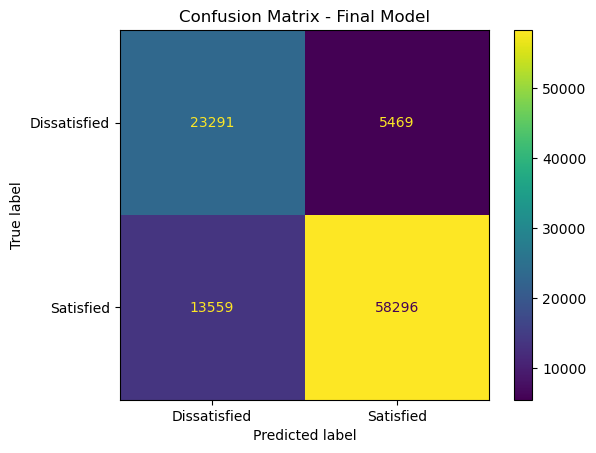

[[23291  5469]
 [13559 58296]]


In [21]:
cm = confusion_matrix(
    y_test,
    y_pred_bigram,
    labels=["Dissatisfied", "Satisfied"]
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Dissatisfied", "Satisfied"]
)

disp.plot()
plt.title("Confusion Matrix - Final Model")
plt.show()

print(cm)

The confusion matrix shows that the final model correctly identified 23,291 dissatisfied reviews and 58,296 satisfied reviews. However, 5,469 dissatisfied reviews were classified as satisfied, while 13,559 satisfied reviews were incorrectly flagged as dissatisfied. The model therefore identifies most dissatisfied reviews, but some dissatisfied customers may still be missed.

## 6. Business Interpretation and Recommendations

The final Logistic Regression model achieved approximately 81.1% accuracy and a recall of approximately 81.1% for the Dissatisfied class. This means the model can identify a substantial proportion of potentially dissatisfied reviews and can therefore be useful for screening large volumes of customer feedback.

The confusion matrix shows that some dissatisfied reviews are still classified as satisfied, while some satisfied reviews are incorrectly flagged. Therefore, the model should be used to prioritise reviews for attention rather than to make fully automated decisions about individual customers.

In [22]:
feature_names = tfidf_bigram.get_feature_names_out()
coefficients = logistic_bigram.coef_[0]

feature_importance = pd.DataFrame({
    "feature": feature_names,
    "coefficient": coefficients
})

print("Features associated with Satisfied:")
print(
    feature_importance.nlargest(10, "coefficient")
    [["feature", "coefficient"]]
)

print("\nFeatures associated with Dissatisfied:")
print(
    feature_importance.nsmallest(10, "coefficient")
    [["feature", "coefficient"]]
)

Features associated with Satisfied:
         feature  coefficient
28928  excellent    10.469409
3781     amazing     8.595022
30564  fantastic     8.363751
36351      great     8.312944
63330    perfect     8.007551
98659  wonderful     7.918746
79843     superb     7.047506
49054      loved     6.552003
11571  beautiful     6.526594
49080     lovely     5.968831

Features associated with Dissatisfied:
         feature  coefficient
71329       rude    -7.768405
24831      dirty    -7.242487
56126        not    -6.925872
64763       poor    -6.711688
99086      worst    -6.450042
81041   terrible    -6.105320
86262      tired    -5.839225
9715       awful    -5.747735
90060  unhelpful    -5.588120
22885      dated    -5.557238


The model coefficients indicate which words and short phrases are strongly associated with each class. Positive terms such as "excellent" and "fantastic" are associated with Satisfied reviews, while terms such as "rude", "dirty" and "poor" are associated with Dissatisfied reviews. These patterns can help hotels identify language related to positive and negative customer experiences.

The coefficients represent associations learned from the training data and should not be interpreted as direct causes of customer satisfaction or dissatisfaction.

### Business Recommendations

Based on the model results, hotels could:

1. **Prioritise potentially dissatisfied reviews:** Use model predictions to identify reviews that may require faster staff attention and service recovery.

2. **Identify recurring problems:** Examine frequently occurring negative terms to identify issues such as cleanliness, staff behaviour or outdated facilities.

3. **Combine automated screening with human review:** Use the model as a decision-support tool rather than replacing human judgement.

4. **Retrain with new feedback:** Periodically update the model using newer customer reviews so that the system can adapt to changes in customer language and hotel services.

## 7. Final Discussion and Conclusion

This project created an end-to-end NLP Pipeline to classify a hotel review as Satisfied or Dissatisfied. The text of the review was transformed into TF-IDF features and three modelling approaches were compared. Overall the Logistic Regression model with unigram and bigram features performed best, with about 81.1% accuracy and 81.1% recall for Dissatisfied class.

One of the major advantages of this approach is its scalability. The model can analyze written feedback in large quantities automatically, and detect reviews that may need more attention. The ability of the model to recognize individual words as well as short phrases is also a benefit from using unigrams and bigrams.

There are more positive than negative reviews in the data. For the model training, class weighting was applied and the accuracy was measured along with precision, recall and F1-score for each class. This gives a fairer assessment than accuracy.

The model has some drawbacks, however. There exists a risk of some dissatisfied reviews or being satisfied, which might mean that some customers requiring attention are missed. There are also false positives, so that some positive reviews which are satisfactory may be unnecessarily marked. Furthermore, the satisfaction threshold of 7.5 is an operating one that was developed for this project and might not be the same as that of other hotels.

The model is based primarily on the meaning of the words and phrases in the reviews and may not capture context, sarcasm or other more complex language. The results are thus to be understood as a support for decision making and not as a substitute for human judgment.

In general, the results show that NLP has the potential to assist in analyzing customer feedback from hotels on a large scale. The model can be applied by hotels to identify and prioritize potentially poor customer reviews, explore common customer-service concerns, and facilitate quicker response time. The NLP models might be more sophisticated in future and the system could be retrained with more recent customer feedback.

## References

Kaggle (n.d.) *515K Hotel Reviews Data in Europe*. Available at:
https://www.kaggle.com/datasets/jiashenliu/515k-hotel-reviews-data-in-europe
(Accessed: 15 September 2026).

Manning, C.D., Raghavan, P. and Schütze, H. (2008) *Introduction to Information Retrieval*. Cambridge: Cambridge University Press. doi:10.1017/CBO9780511809071.

scikit-learn (2026a) *TfidfVectorizer*. Available at:
https://scikit-learn.org/stable/modules/generated/sklearn.feature_extraction.text.TfidfVectorizer.html
(Accessed: 15 September 2026).

scikit-learn (2026b) *LogisticRegression*. Available at:
https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html
(Accessed: 15 September 2026).